# Breast Thermography 3D Reconstruction (DMR-IR) - Orthographic Geometric Pipeline

**Scope:** Pure geometric 2.5D reconstruction from five segmented thermal views (0 deg, +/-45 deg, +/-90 deg).  
**Goal:** Reconstruct a smooth 3D NURBS-like breast surface and extract asymmetry descriptors for downstream NNMF-ReliefF and Ensemble CNN analysis.  
**Framework:** NumPy + PyTorch + SciPy (edge-computing friendly).

---

## Protocol lock (Moura VISAPP 2024/2025 aligned)

1. Input is a 1-pixel skeletonized contour from semantic segmentation (256x256).
2. Phase 3 uses anatomical anchors (P1, P2, P3) with strict lateral clipping.
3. Phase 4 rotates around anatomical pivots (never camera center).
4. Phase 4 follows Algorithm 1 rigid registration: move local P2 to origin, rotate, then translate to frontal P1 or P3 target anchor.
5. Phase 5 surface interpolation uses B-spline fitting with degree 4 (`kx=4`, `ky=4`) and evaluation step `0.01` in parametric space.
6. Phase 6 outputs numeric geometry features, not only rendered figures.

This notebook includes reference functions that follow these constraints directly.

---

## Phase 1 - Data Loading and Normalization

This phase pairs each thermal TIFF with its binary mask, resizes both to $256 \times 256$, and converts them to tensors suitable for U-Net input.

The thermal image is min-max normalized to preserve temperature contrast while mapping values into a stable learning range:

$$
m_{ij} = \frac{P_{ij} - \min(P)}{\max(P) - \min(P)}
$$

This is equivalent to the paper's normalized intensity step before model training.

In [6]:
%pip install torch torchvision tifffile opencv-python scikit-learn matplotlib pandas seaborn tensorflow keras cv2


  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [7]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


### 1.1 ThermalDataset class

The dataset class performs three important jobs:

1. Finds mask files recursively and uses them as the reference sample list.
2. Locates each TIFF robustly using filename-prefix matching to avoid Unicode mismatches (for example degree-symbol variants).
3. Returns image-mask pairs as shape $(1, H, W)$ tensors so they are immediately compatible with the U-Net input/output format.

This design is intentionally defensive for Windows path and encoding edge cases.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split
import tifffile as tiff
import cv2
import numpy as np
import os
import glob

# ── FIX 2: Reproducibility seed ──────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


class ThermalDataset(Dataset):
    def __init__(self, tiff_dir, mask_dir):
        # We find all masks first as they represent our ground truth batch
        self.mask_paths = glob.glob(os.path.join(mask_dir, "**", "*.png"), recursive=True)
        self.tiff_dir = tiff_dir
        self.mask_dir = mask_dir
        print(f"Dataset initialized with {len(self.mask_paths)} masks.")

    def __len__(self):
        return len(self.mask_paths)

    def __getitem__(self, idx):
        mask_path = self.mask_paths[idx]

        # 1. Get the patient folder and filename (e.g., Patient_106/benign/Right Lateral...)
        rel_path = os.path.relpath(mask_path, self.mask_dir)
        patient_subfolder = os.path.dirname(rel_path)
        mask_filename = os.path.basename(rel_path)

        # 2. Robust TIFF Search: Find the TIFF that matches the mask name
        # We search the folder directly to avoid encoding mismatches with the degree symbol
        tiff_search_folder = os.path.join(self.tiff_dir, patient_subfolder)
        base_name = os.path.splitext(mask_filename)[0]

        # We use a wildcard search to find the .tiff file matching the start of the mask name
        # This bypasses the specific encoding of the (90°) part
        search_pattern = os.path.join(tiff_search_folder, "*.tiff")
        potential_tiffs = glob.glob(search_pattern)

        tiff_path = None
        for p_tiff in potential_tiffs:
            if base_name[:10] in os.path.basename(p_tiff):  # Match first 10 chars (e.g., 'Right Late')
                tiff_path = p_tiff
                break

        if tiff_path is None or not os.path.exists(tiff_path):
            raise FileNotFoundError(f"Could not find matching TIFF for {mask_path}")

        # 3. Load and Normalize TIFF (Paper Eq 1) [cite: 113]
        raw_data = tiff.imread(tiff_path)
        t_min, t_max = np.min(raw_data), np.max(raw_data)

        # Prevent division by zero
        if t_max == t_min:
            normalized = np.zeros_like(raw_data, dtype=np.float32)
        else:
            normalized = (raw_data - t_min) / (t_max - t_min)

        img_256 = cv2.resize(normalized.astype(np.float32), (256, 256), interpolation=cv2.INTER_AREA)

        # 4. Load Mask
        # Use np.fromfile to bypass Windows encoding issues with the degree symbol (°)
        img_array = np.fromfile(mask_path, dtype=np.uint8)
        mask = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not read mask file (might be corrupted or empty): {mask_path}")
        mask_256 = cv2.resize(mask, (256, 256)).astype(np.float32) / 255.0

        # Return as (C, H, W) tensors
        return torch.from_numpy(img_256).unsqueeze(0), torch.from_numpy(mask_256).unsqueeze(0)


# Paths in Thinkpad environment (adjust as needed)
TIFF_BASE = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\organized_by_patient"
MASK_BASE = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\GroundTruth_Masks"

# Paths in Thinkpad environment (adjust as needed)
# TIFF_BASE = r"C:\Users\User\Documents\Skripsi Faiz_DL\DNP-3DDMR-IR\data\organized_by_patient"
# MASK_BASE = r"C:\Users\User\Documents\Skripsi Faiz_DL\DNP-3DDMR-IR\data\GroundTruth_Masks"

# ── FIX 1: Train / test split — 78 % / 22 % per paper §3.3 ──────────────────
full_dataset = ThermalDataset(TIFF_BASE, MASK_BASE)
n_total = len(full_dataset)
n_train = int(0.78 * n_total)
n_test  = n_total - n_train
train_set, test_set = random_split(
    full_dataset, [n_train, n_test],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Split: {n_train} train / {n_test} test  (total={n_total})")

train_loader = DataLoader(train_set, batch_size=2, shuffle=True)   # Batch size 2 as per paper
test_loader  = DataLoader(test_set,  batch_size=2, shuffle=False)


Dataset initialized with 162 masks.
Split: 126 train / 36 test  (total=162)


### 1.2 Training-time augmentation

To reduce overfitting on a limited medical dataset, augmentation is applied only to training batches.

- Horizontal flip is applied to both image and mask so spatial correspondence remains correct.
- Brightness jitter is applied only to the thermal image.

This keeps anatomical geometry valid while improving generalization.

In [9]:
# ── FIX 3: Data augmentation ─────────────────────────────────────────────────
def augment(img_tensor, mask_tensor):
    """Random horizontal flip + brightness jitter. Applied to both image and mask."""
    # Random horizontal flip — applied identically to image and mask
    if torch.rand(1).item() > 0.5:
        img_tensor  = TF.hflip(img_tensor)
        mask_tensor = TF.hflip(mask_tensor)

    # Random brightness jitter on image only (masks are binary)
    if torch.rand(1).item() > 0.5:
        factor     = 0.8 + torch.rand(1).item() * 0.4  # uniform in [0.8, 1.2]
        img_tensor = torch.clamp(img_tensor * factor, 0.0, 1.0)

    return img_tensor, mask_tensor


---

## Phase 2 - U-Net Architecture (Stronger V2)

The model is now a **4-level encoder-decoder U-Net** with skip connections, BatchNorm, dropout regularization, and He initialization for better convergence stability.

Each block uses:

$\text{Conv}(3\times3) \rightarrow \text{BN} \rightarrow \text{ReLU} \rightarrow \text{Conv}(3\times3) \rightarrow \text{BN} \rightarrow \text{ReLU}$

### Channel flow

| Stage | Channels |
|---|---|
| Encoder 1 | 1 -> 64 |
| Encoder 2 | 64 -> 128 |
| Encoder 3 | 128 -> 256 |
| Encoder 4 | 256 -> 512 |
| Bottleneck | 512 -> 1024 |
| Decoder 4 | 1024 -> 512 |
| Decoder 3 | 512 -> 256 |
| Decoder 2 | 256 -> 128 |
| Decoder 1 | 128 -> 64 |
| Output | 64 -> 1 (logits) |

The output layer returns **logits** (no sigmoid in the model head). Sigmoid is applied only when computing Dice/visualization/inference thresholding.

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=64, dropout=0.2):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        # Encoder (4 levels)
        self.enc1 = DoubleConv(in_channels, base_channels, dropout=0.0)
        self.enc2 = DoubleConv(base_channels, base_channels * 2, dropout=0.0)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4, dropout=0.1)
        self.enc4 = DoubleConv(base_channels * 4, base_channels * 8, dropout=0.1)

        # Bottleneck
        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16, dropout=dropout)

        # Decoder
        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_channels * 16, base_channels * 8, dropout=0.1)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4, dropout=0.1)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2, dropout=0.0)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels, dropout=0.0)

        # Output logits (no sigmoid here)
        self.out = nn.Conv2d(base_channels, out_channels, kernel_size=1)

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.constant_(module.weight, 1)
            nn.init.constant_(module.bias, 0)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready on: {device} | trainable params: {num_params:,}")

Model ready on: cuda | trainable params: 31,036,481


### 2.1 Dice coefficient metric

Binary cross-entropy is used for optimization, but Dice is the key overlap metric for segmentation quality.

Dice is computed as:

$$
\text{Dice} = \frac{2|A \cap B| + \epsilon}{|A| + |B| + \epsilon}
$$

where $A$ is the thresholded prediction and $B$ is the ground-truth mask.

In [11]:
# ── Dice coefficient that supports logits ─────────────────────────────────────
def dice_coeff(pred, target, threshold=0.5, eps=1e-6, from_logits=True):
    """Dice over batch. pred/target shape: (B,1,H,W)."""
    if from_logits:
        pred = torch.sigmoid(pred)
    pred_bin = (pred > threshold).float()

    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    denominator = pred_bin.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return dice.mean()

---

### 2.2 Training loop (AdamW + BCEWithLogits+Dice + early stopping)

| Hyperparameter | Value |
|---|---|
| Loss | $0.6\times\text{BCEWithLogits} + 0.4\times\text{DiceLoss}$ |
| Optimizer | AdamW |
| Learning rate | $3 \times 10^{-4}$ (adaptive via ReduceLROnPlateau) |
| Weight decay | $1 \times 10^{-4}$ |
| Batch size | 2 |
| Max epochs | 120 |
| Early stopping patience | 12 epochs without val-Dice improvement |
| Stability tricks | AMP (CUDA), gradient clipping (1.0) |

The loop logs train loss, train Dice, validation Dice, and learning rate.  
Best validation-Dice weights are saved immediately to preserve the strongest checkpoint.

In [2]:
%pip install tqdm ipywidgets


  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 16.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 35.2 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [tqdm]
   ---------- ----------------------------- 1/4 [tqdm]
   ------------------------------ --------- 3/4 [ipywidgets]
   ------------------------------ --------- 3/4 [ipywidgets]
   ------------------------------ --------- 3/4 [ipywidgets]
   ---------------------------------------- 4/4 [ipywidgets]

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from tqdm.notebook import tqdm  # Progress bar for Jupyter / VS Code

In [15]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.6, dice_weight=0.4, eps=1e-6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.eps = eps

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)

        intersection = (probs * targets).sum(dim=(1, 2, 3))
        denom = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice = (2.0 * intersection + self.eps) / (denom + self.eps)
        dice_loss = 1.0 - dice.mean()

        total = self.bce_weight * bce_loss + self.dice_weight * dice_loss
        return total, bce_loss.detach(), dice_loss.detach()


criterion = BCEDiceLoss(bce_weight=0.6, dice_weight=0.4)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
 )

num_epochs = 120
patience = 12
best_dice = 0.0
epochs_no_imp = 0
best_ckpt = "breast_segmentation_unet_best.pth"

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

print(f"Starting Training on {device}...")
print(f"Early stopping: patience={patience}, monitoring=val Dice")
print("Loss: 0.6*BCEWithLogits + 0.4*DiceLoss")

epoch_train_losses = []
epoch_train_dices = []
epoch_val_dices = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_dice = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for imgs, masks in progress_bar:
        imgs, masks = augment(imgs, masks)
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(imgs)
            loss, bce_part, dice_part = criterion(logits, masks)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        current_loss = loss.item()
        current_dice = dice_coeff(logits.detach(), masks, from_logits=True).item()

        epoch_loss += current_loss
        epoch_dice += current_dice
        progress_bar.set_postfix(
            loss=f"{current_loss:.4f}",
            dice=f"{current_dice:.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.1e}"
        )

    avg_loss = epoch_loss / len(train_loader)
    avg_dice = epoch_dice / len(train_loader)

    model.eval()
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            val_dice += dice_coeff(logits, masks, from_logits=True).item()
    val_dice /= len(test_loader)

    scheduler.step(val_dice)

    epoch_train_losses.append(avg_loss)
    epoch_train_dices.append(avg_dice)
    epoch_val_dices.append(val_dice)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1:03d}/{num_epochs}] "
            f"Loss: {avg_loss:.4f}  Train Dice: {avg_dice:.4f}  "
            f"Val Dice: {val_dice:.4f}  LR: {optimizer.param_groups[0]['lr']:.1e}"
        )

    if val_dice > best_dice:
        best_dice = val_dice
        epochs_no_imp = 0
        torch.save(model.state_dict(), best_ckpt)
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= patience:
            print(
                f"\nEarly stopping at epoch {epoch+1} — "
                f"no Val Dice improvement for {patience} epochs."
            )
            print(f"Best Val Dice: {best_dice:.4f}  →  weights saved to '{best_ckpt}'")
            break

torch.save(model.state_dict(), "breast_segmentation_unet.pth")
print("\nTraining complete.")
print("  Last weights : breast_segmentation_unet.pth")
print(f"  Best weights : {best_ckpt}  (Val Dice: {best_dice:.4f})")

Starting Training on cpu...
Early stopping: patience=12, monitoring=val Dice
Loss: 0.6*BCEWithLogits + 0.4*DiceLoss


Epoch 1/120:   0%|          | 0/63 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [2]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement torchaudio (from versions: none)
ERROR: No matching distribution found for torchaudio


In [26]:

pip install nvidia-pyindex

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build nvidia-pyindex
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for nvidia-pyindex (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [130 lines of output]
      <string>:235: DeprecationWarning: codecs.open() is deprecated. Use open() instead.
      C:\Users\User\AppData\Local\Temp\pip-build-env-u6wk2rjb\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: Apache Software License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ********************************************************************************
      
      !!
        self._finalize_license_expression()
      ru

In [28]:
pip install nvidia-cuda-runtime-cu12

   ---------------------------------------- 0.0/3.6 MB ? eta -:--:--
   ------------------------------------- -- 3.4/3.6 MB 40.9 MB/s eta 0:00:01
   ---------------------------------------- 3.6/3.6 MB 17.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [14]:
# Cell 17 (RTX 3060 optimized): Standalone GPU training
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU not detected. Please switch to a CUDA-enabled environment.")

required = ["UNet", "full_dataset", "train_set", "test_set", "dice_coeff", "augment"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing prerequisites: {missing}. Run the setup cells for dataset and model utilities first."
    )

gpu_device = torch.device("cuda")
gpu_name = torch.cuda.get_device_name(0)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

# RTX 3060-friendly defaults
train_batch_size = 4   # safe starting point for most RTX 3060 rigs
eval_batch_size = 4

train_loader_gpu = DataLoader(
    train_set,
    batch_size=train_batch_size,
    shuffle=True,
    pin_memory=True,
    num_workers=0,
 )
test_loader_gpu = DataLoader(
    test_set,
    batch_size=eval_batch_size,
    shuffle=False,
    pin_memory=True,
    num_workers=0,
 )

# Local loss class in case Cell 16 was not run
if "BCEDiceLoss" not in globals():
    class BCEDiceLoss(nn.Module):
        def __init__(self, bce_weight=0.6, dice_weight=0.4, eps=1e-6):
            super().__init__()
            self.bce = nn.BCEWithLogitsLoss()
            self.bce_weight = bce_weight
            self.dice_weight = dice_weight
            self.eps = eps

        def forward(self, logits, targets):
            bce_loss = self.bce(logits, targets)
            probs = torch.sigmoid(logits)
            inter = (probs * targets).sum(dim=(1, 2, 3))
            denom = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
            dice = (2.0 * inter + self.eps) / (denom + self.eps)
            dice_loss = 1.0 - dice.mean()
            total = self.bce_weight * bce_loss + self.dice_weight * dice_loss
            return total, bce_loss.detach(), dice_loss.detach()

# Fresh training objects (independent from Cell 16)
model = UNet().to(gpu_device, memory_format=torch.channels_last)
criterion = BCEDiceLoss(bce_weight=0.6, dice_weight=0.4)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
 )
scaler = torch.amp.GradScaler("cuda", enabled=True)

gpu_epochs = 60
gpu_patience = 10
epochs_no_imp = 0
best_gpu_dice = 0.0
best_gpu_ckpt = "breast_segmentation_unet_best_gpu.pth"

if "epoch_train_losses" not in globals():
    epoch_train_losses = []
if "epoch_train_dices" not in globals():
    epoch_train_dices = []
if "epoch_val_dices" not in globals():
    epoch_val_dices = []

print(f"Using GPU: {gpu_name}")
print(f"Starting standalone GPU training on: {gpu_device}")
print(f"Train batch size: {train_batch_size} | Eval batch size: {eval_batch_size}")
print(f"Epochs={gpu_epochs}, EarlyStop patience={gpu_patience}")

for ep in range(gpu_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_dice = 0.0

    gpu_bar = tqdm(train_loader_gpu, desc=f"GPU Epoch {ep+1}/{gpu_epochs}", leave=False)
    for imgs, masks in gpu_bar:
        imgs, masks = augment(imgs, masks)
        imgs = imgs.to(gpu_device, non_blocking=True).contiguous(memory_format=torch.channels_last)
        masks = masks.to(gpu_device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=True):
            logits = model(imgs)
            loss, _, _ = criterion(logits, masks)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        batch_dice = dice_coeff(logits.detach(), masks, from_logits=True).item()
        epoch_loss += loss.item()
        epoch_dice += batch_dice
        gpu_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            dice=f"{batch_dice:.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.1e}"
        )

    avg_loss = epoch_loss / len(train_loader_gpu)
    avg_dice = epoch_dice / len(train_loader_gpu)

    model.eval()
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in test_loader_gpu:
            imgs = imgs.to(gpu_device, non_blocking=True).contiguous(memory_format=torch.channels_last)
            masks = masks.to(gpu_device, non_blocking=True)
            logits = model(imgs)
            val_dice += dice_coeff(logits, masks, from_logits=True).item()
    val_dice /= len(test_loader_gpu)

    scheduler.step(val_dice)

    epoch_train_losses.append(avg_loss)
    epoch_train_dices.append(avg_dice)
    epoch_val_dices.append(val_dice)

    if val_dice > best_gpu_dice:
        best_gpu_dice = val_dice
        epochs_no_imp = 0
        torch.save(model.state_dict(), best_gpu_ckpt)
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= gpu_patience:
            print(
                f"\nEarly stopping at GPU epoch {ep+1} — "
                f"no Val Dice improvement for {gpu_patience} epochs."
            )
            break

    if (ep + 1) % 5 == 0 or ep == 0:
        print(
            f"[GPU {ep+1:03d}/{gpu_epochs}] Loss: {avg_loss:.4f} "
            f"Train Dice: {avg_dice:.4f}  Val Dice: {val_dice:.4f} "
            f"LR: {optimizer.param_groups[0]['lr']:.1e}"
        )

torch.save(model.state_dict(), "breast_segmentation_unet_gpu_last.pth")
print("\nStandalone GPU training complete.")
print(f"Best GPU Val Dice : {best_gpu_dice:.4f}")
print(f"Best GPU checkpoint: {best_gpu_ckpt}")
print("Last GPU checkpoint: breast_segmentation_unet_gpu_last.pth")

Using GPU: NVIDIA GeForce RTX 3060
Starting standalone GPU training on: cuda
Train batch size: 4 | Eval batch size: 4
Epochs=60, EarlyStop patience=10


GPU Epoch 1/60:   0%|          | 0/32 [00:00<?, ?it/s]

[GPU 001/60] Loss: 1.0679 Train Dice: 0.3754  Val Dice: 0.3598 LR: 3.0e-04


GPU Epoch 2/60:   0%|          | 0/32 [00:00<?, ?it/s]

GPU Epoch 3/60:   0%|          | 0/32 [00:00<?, ?it/s]

...

GPU Epoch 37/60:   0%|          | 0/32 [00:00<?, ?it/s]

GPU Epoch 38/60:   0%|          | 0/32 [00:00<?, ?it/s]

GPU Epoch 39/60:   0%|          | 0/32 [00:00<?, ?it/s]

GPU Epoch 40/60:   0%|          | 0/32 [00:00<?, ?it/s]


Early stopping at GPU epoch 40 — no Val Dice improvement for 10 epochs.

Standalone GPU training complete.
Best GPU Val Dice : 0.8962
Best GPU checkpoint: breast_segmentation_unet_best_gpu.pth
Last GPU checkpoint: breast_segmentation_unet_gpu_last.pth


#### Optional manual checkpoint

Use this cell when you want an extra named snapshot (for example, after a specific epoch milestone).

This does not replace the best-checkpoint logic; it adds a manual archive point for experiments.

In [46]:
torch.save(model.state_dict(), "breast_segmentation_unet_v1_60epochs.pth")
print("Weights saved successfully!")


Weights saved successfully!


### 2.3 Held-out test evaluation

This section evaluates the trained model on the held-out split (22% test subset).

Reported outputs:

- Mean BCE loss ± standard deviation
- Mean Dice score ± standard deviation

These values summarize both pixel-wise classification quality (BCE) and geometric overlap quality (Dice).

In [1]:
# Evaluate on held-out test set (logits-aware)
model.eval()
test_losses = []
test_dices = []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss, _, _ = criterion(logits, masks)

        test_losses.append(loss.item())
        test_dices.append(dice_coeff(logits, masks, from_logits=True).item())

print(f"Test Loss (BCE+Dice) : {np.mean(test_losses):.4f} ± {np.std(test_losses):.4f}")
print(f"Test Dice             : {np.mean(test_dices):.4f} ± {np.std(test_dices):.4f}")

NameError: name 'model' is not defined

---

### 2.4 Qualitative prediction check

This visualization plots one test sample as:

1. Input thermal image
2. Ground-truth mask
3. U-Net predicted mask

Use it as a quick sanity check before running full inference on all patient views.

In [4]:
%pip install matplotlib


  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 26.2 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- --------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt

# 1. Visualize the Loss and Dice Scores
def plot_metrics(train_losses, val_dices, train_dices=None):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Plot 1: BCE Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss (BCE+Dice)')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot 2: Dice Coefficient (Validation vs Train if available)
    plt.subplot(1, 2, 2)
    if train_dices:
        plt.plot(epochs, train_dices, 'b-', label='Train Dice')
    plt.plot(epochs, val_dices, 'g-', label='Validation Dice', linewidth=2)
    
    # Highlight the best epoch
    best_epoch = val_dices.index(max(val_dices)) + 1
    plt.plot(best_epoch, max(val_dices), 'ro', label=f'Best Val Dice (Epoch {best_epoch})')

    plt.title('Dice Coefficient (Higher is Better)')
    plt.xlabel('Epochs')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Extract the tracked metrics from the training loop variables
# (Assuming you appended the avg_loss and val_dice to lists during the loop)
# Note: You will need to slightly modify the training loop above to append these values to lists:
# e.g., epoch_train_losses.append(avg_loss), epoch_val_dices.append(val_dice)

try:
    plot_metrics(epoch_train_losses, epoch_val_dices)
except NameError:
     print("Could not plot metrics. Ensure you are appending 'avg_loss' and 'val_dice' to lists named 'epoch_train_losses' and 'epoch_val_dices' inside your training loop.")

Could not plot metrics. Ensure you are appending 'avg_loss' and 'val_dice' to lists named 'epoch_train_losses' and 'epoch_val_dices' inside your training loop.


In [3]:
# 2. Final Model Save Configuration (GPU checkpoint, no stale variable dependency)
print("\n--- Saving Final Model ---")
final_model_path = "breast_segmentation_unet_gpu.pth"
source_ckpt = "breast_segmentation_unet_best_gpu.pth"

if not os.path.exists(source_ckpt):
    raise FileNotFoundError(
        f"Required checkpoint not found: {source_ckpt}. "
        "Run GPU training first (Cell 20) to generate it."
    )

# Load the GPU-best weights and save under a clear final name
model.load_state_dict(torch.load(source_ckpt, weights_only=True))
torch.save(model.state_dict(), final_model_path)
print(f"Successfully saved the highest-performing model as: {final_model_path}")
print(f"Source checkpoint: {source_ckpt}")
print(f"You can now use '{final_model_path}' in Phase 3 for automated segmentation.")


--- Saving Final Model ---


NameError: name 'os' is not defined

In [2]:
import matplotlib.pyplot as plt
import random

viz_ckpt = "breast_segmentation_unet_best_gpu.pth"
if not os.path.exists(viz_ckpt):
    raise FileNotFoundError(
        f"Visualization checkpoint not found: {viz_ckpt}. "
        "Run GPU training first (Cell 20)."
    )

# Always visualize with the newest GPU-best weights (avoid stale in-memory model state).
model.load_state_dict(torch.load(viz_ckpt, weights_only=True))
model.eval()

with torch.no_grad():
    sample_idx = random.randrange(len(test_set))
    img, mask = test_set[sample_idx]

    img = img.unsqueeze(0).to(device)
    mask = mask.unsqueeze(0)

    logits = model(img)
    pred = torch.sigmoid(logits)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img[0, 0].cpu(), cmap='magma')
    axs[0].set_title(f"Input Thermal (TIFF) - Sample #{sample_idx}")
    axs[1].imshow(mask[0, 0].cpu(), cmap='gray')
    axs[1].set_title("Manual Mask")
    axs[2].imshow(pred[0, 0].cpu(), cmap='gray')
    axs[2].set_title("U-Net Prediction")
    for ax in axs:
        ax.axis('off')
    plt.show()

NameError: name 'model' is not defined

---

## Inference Pipeline - Automated Segmentation and Edge Extraction

This phase applies the trained U-Net to all TIFF files and saves a clean edge map for each image.

Per image, the pipeline does:

1. Min-max normalization
2. Forward pass through U-Net
3. Threshold at 0.5 to create a binary mask
4. Keep only the largest connected contour (noise suppression)
5. Run Canny edge detection on the cleaned mask
6. Save output as <original_name>_edge.png while preserving folder structure

The edge outputs become the direct input for anchor extraction in Phase 3.

In [4]:
output_edges = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3"


In [5]:
def automated_segmentation(model_path, tiff_dir, output_dir):
    model = UNet().to(device)
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.eval()

    all_tiffs = glob.glob(os.path.join(tiff_dir, "**", "*.tiff"), recursive=True)
    os.makedirs(output_dir, exist_ok=True)

    print(f"Running automated segmentation on {len(all_tiffs)} images...")
    print(f"Model checkpoint: {model_path}")
    print(f"Output edge dir : {output_dir}")

    for f_path in tqdm(all_tiffs):
        raw = tiff.imread(f_path)
        t_min, t_max = np.min(raw), np.max(raw)
        norm = (raw - t_min) / (t_max - t_min + 1e-8)
        img_256 = cv2.resize(norm.astype(np.float32), (256, 256))

        img_tensor = torch.from_numpy(img_256).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_logits = model(img_tensor)
            pred = torch.sigmoid(pred_logits).squeeze().cpu().numpy()

        binary = (pred > 0.5).astype(np.uint8) * 255

        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        clean_mask = np.zeros_like(binary)
        if not contours:
            print(f"Warning: no contour found for {os.path.basename(f_path)}, skipping.")
            continue

        largest = max(contours, key=cv2.contourArea)
        cv2.drawContours(clean_mask, [largest], -1, 255, thickness=cv2.FILLED)

        edges = cv2.Canny(clean_mask, 100, 200)

        rel_path = os.path.relpath(f_path, tiff_dir)
        out_name = os.path.splitext(rel_path)[0] + "_edge.png"
        save_path = os.path.join(output_dir, out_name)
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cv2.imwrite(save_path, edges)


model_weights = "breast_segmentation_unet_best_gpu.pth"
output_edges = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3"

if not os.path.exists(model_weights):
    raise FileNotFoundError(f"Model checkpoint not found: {model_weights}")

automated_segmentation(model_weights, TIFF_BASE, output_edges)

NameError: name 'os' is not defined

---

### Edge-overlay quality check

This section randomly samples generated edge maps and overlays them in green on top of the original thermal image.

Why this is useful:

- Confirms that model boundaries align with anatomical breast contours.
- Quickly reveals failed masks, empty outputs, or corrupted files.
- Verifies that path handling remains stable on Windows/Unicode filenames.

The helper loader is intentionally robust against zero-byte and encoding-related read errors.

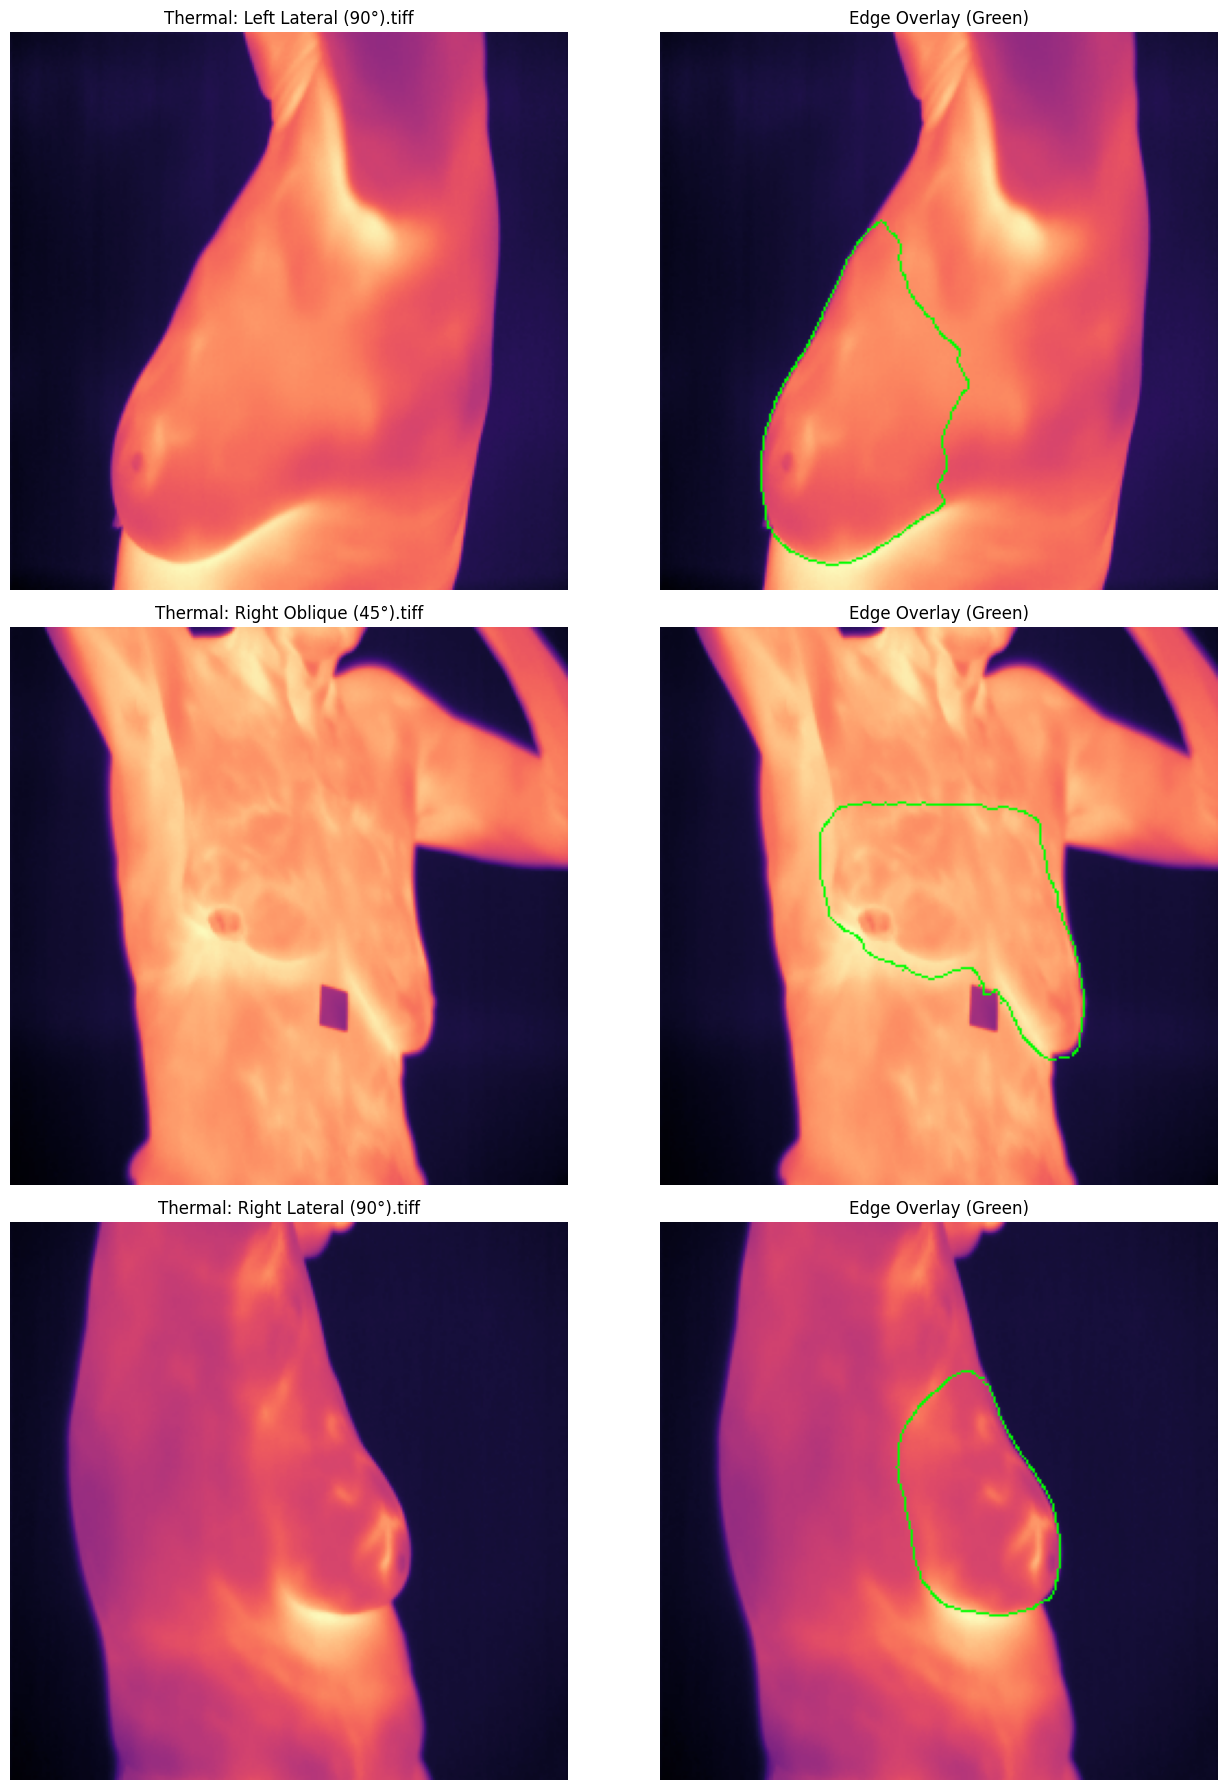

In [5]:
def robust_read_image(path, flags=cv2.IMREAD_GRAYSCALE):
    """Bypasses Windows path encoding issues and handles empty files."""
    try:
        if os.path.getsize(path) == 0:  # Check if file was stopped mid-save
            return None
        # Read file as a numpy array buffer to bypass string encoding
        img_array = np.fromfile(path, dtype=np.uint8)
        img = cv2.imdecode(img_array, flags)
        return img
    except Exception:
        return None


def ultra_robust_light_test(tiff_dir, edge_dir, num_samples=3):
    # 1. Find all generated edge maps
    edge_files = glob.glob(os.path.join(edge_dir, "**", "*_edge.png"), recursive=True)

    if not edge_files:
        print("No edge files found! Check your Automated_Edges folder.")
        return

    # 2. Pick samples and setup plotting
    samples = random.sample(edge_files, min(num_samples, len(edge_files)))
    fig, axs = plt.subplots(len(samples), 2, figsize=(14, 6 * len(samples)))
    if len(samples) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, edge_path in enumerate(samples):
        # --- ROBUST READ ---
        edge_img = robust_read_image(edge_path)

        if edge_img is None:
            print(f"Skipping corrupted or unreadable edge map: {os.path.basename(edge_path)}")
            continue

        # 3. Find corresponding TIFF using Prefix Matching
        rel_path          = os.path.relpath(edge_path, edge_dir)
        patient_subfolder = os.path.dirname(rel_path)
        edge_filename     = os.path.basename(rel_path)
        search_folder     = os.path.join(tiff_dir, patient_subfolder)
        search_prefix     = edge_filename.split('(')[0].strip()

        potential_tiffs = glob.glob(os.path.join(search_folder, "*.tiff"))
        tiff_path = next((p for p in potential_tiffs if search_prefix in os.path.basename(p)), None)

        if tiff_path is None:
            continue

        # 4. Load/Normalize TIFF and Resize to 256x256
        raw      = tiff.imread(tiff_path)
        norm     = 255 * (raw - np.min(raw)) / (np.max(raw) - np.min(raw) + 1e-8)
        norm_256 = cv2.resize(norm.astype(np.uint8), (256, 256), interpolation=cv2.INTER_AREA)
        base_display = cv2.applyColorMap(norm_256, cv2.COLORMAP_MAGMA)

        # 5. Overlay edges
        overlay = base_display.copy()
        # The 'if edge_img is not None' check prevents the TypeError
        overlay[edge_img > 0] = [0, 255, 0]

        # Plotting
        axs[i, 0].imshow(cv2.cvtColor(base_display, cv2.COLOR_BGR2RGB))
        axs[i, 0].set_title(f"Thermal: {os.path.basename(tiff_path)}")
        axs[i, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axs[i, 1].set_title("Edge Overlay (Green)")
        for ax in axs[i]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()


# Execute the test
ultra_robust_light_test(TIFF_BASE, output_edges, num_samples=3)


---

## Phase 3 - Identification of the relevant edge and points of each view

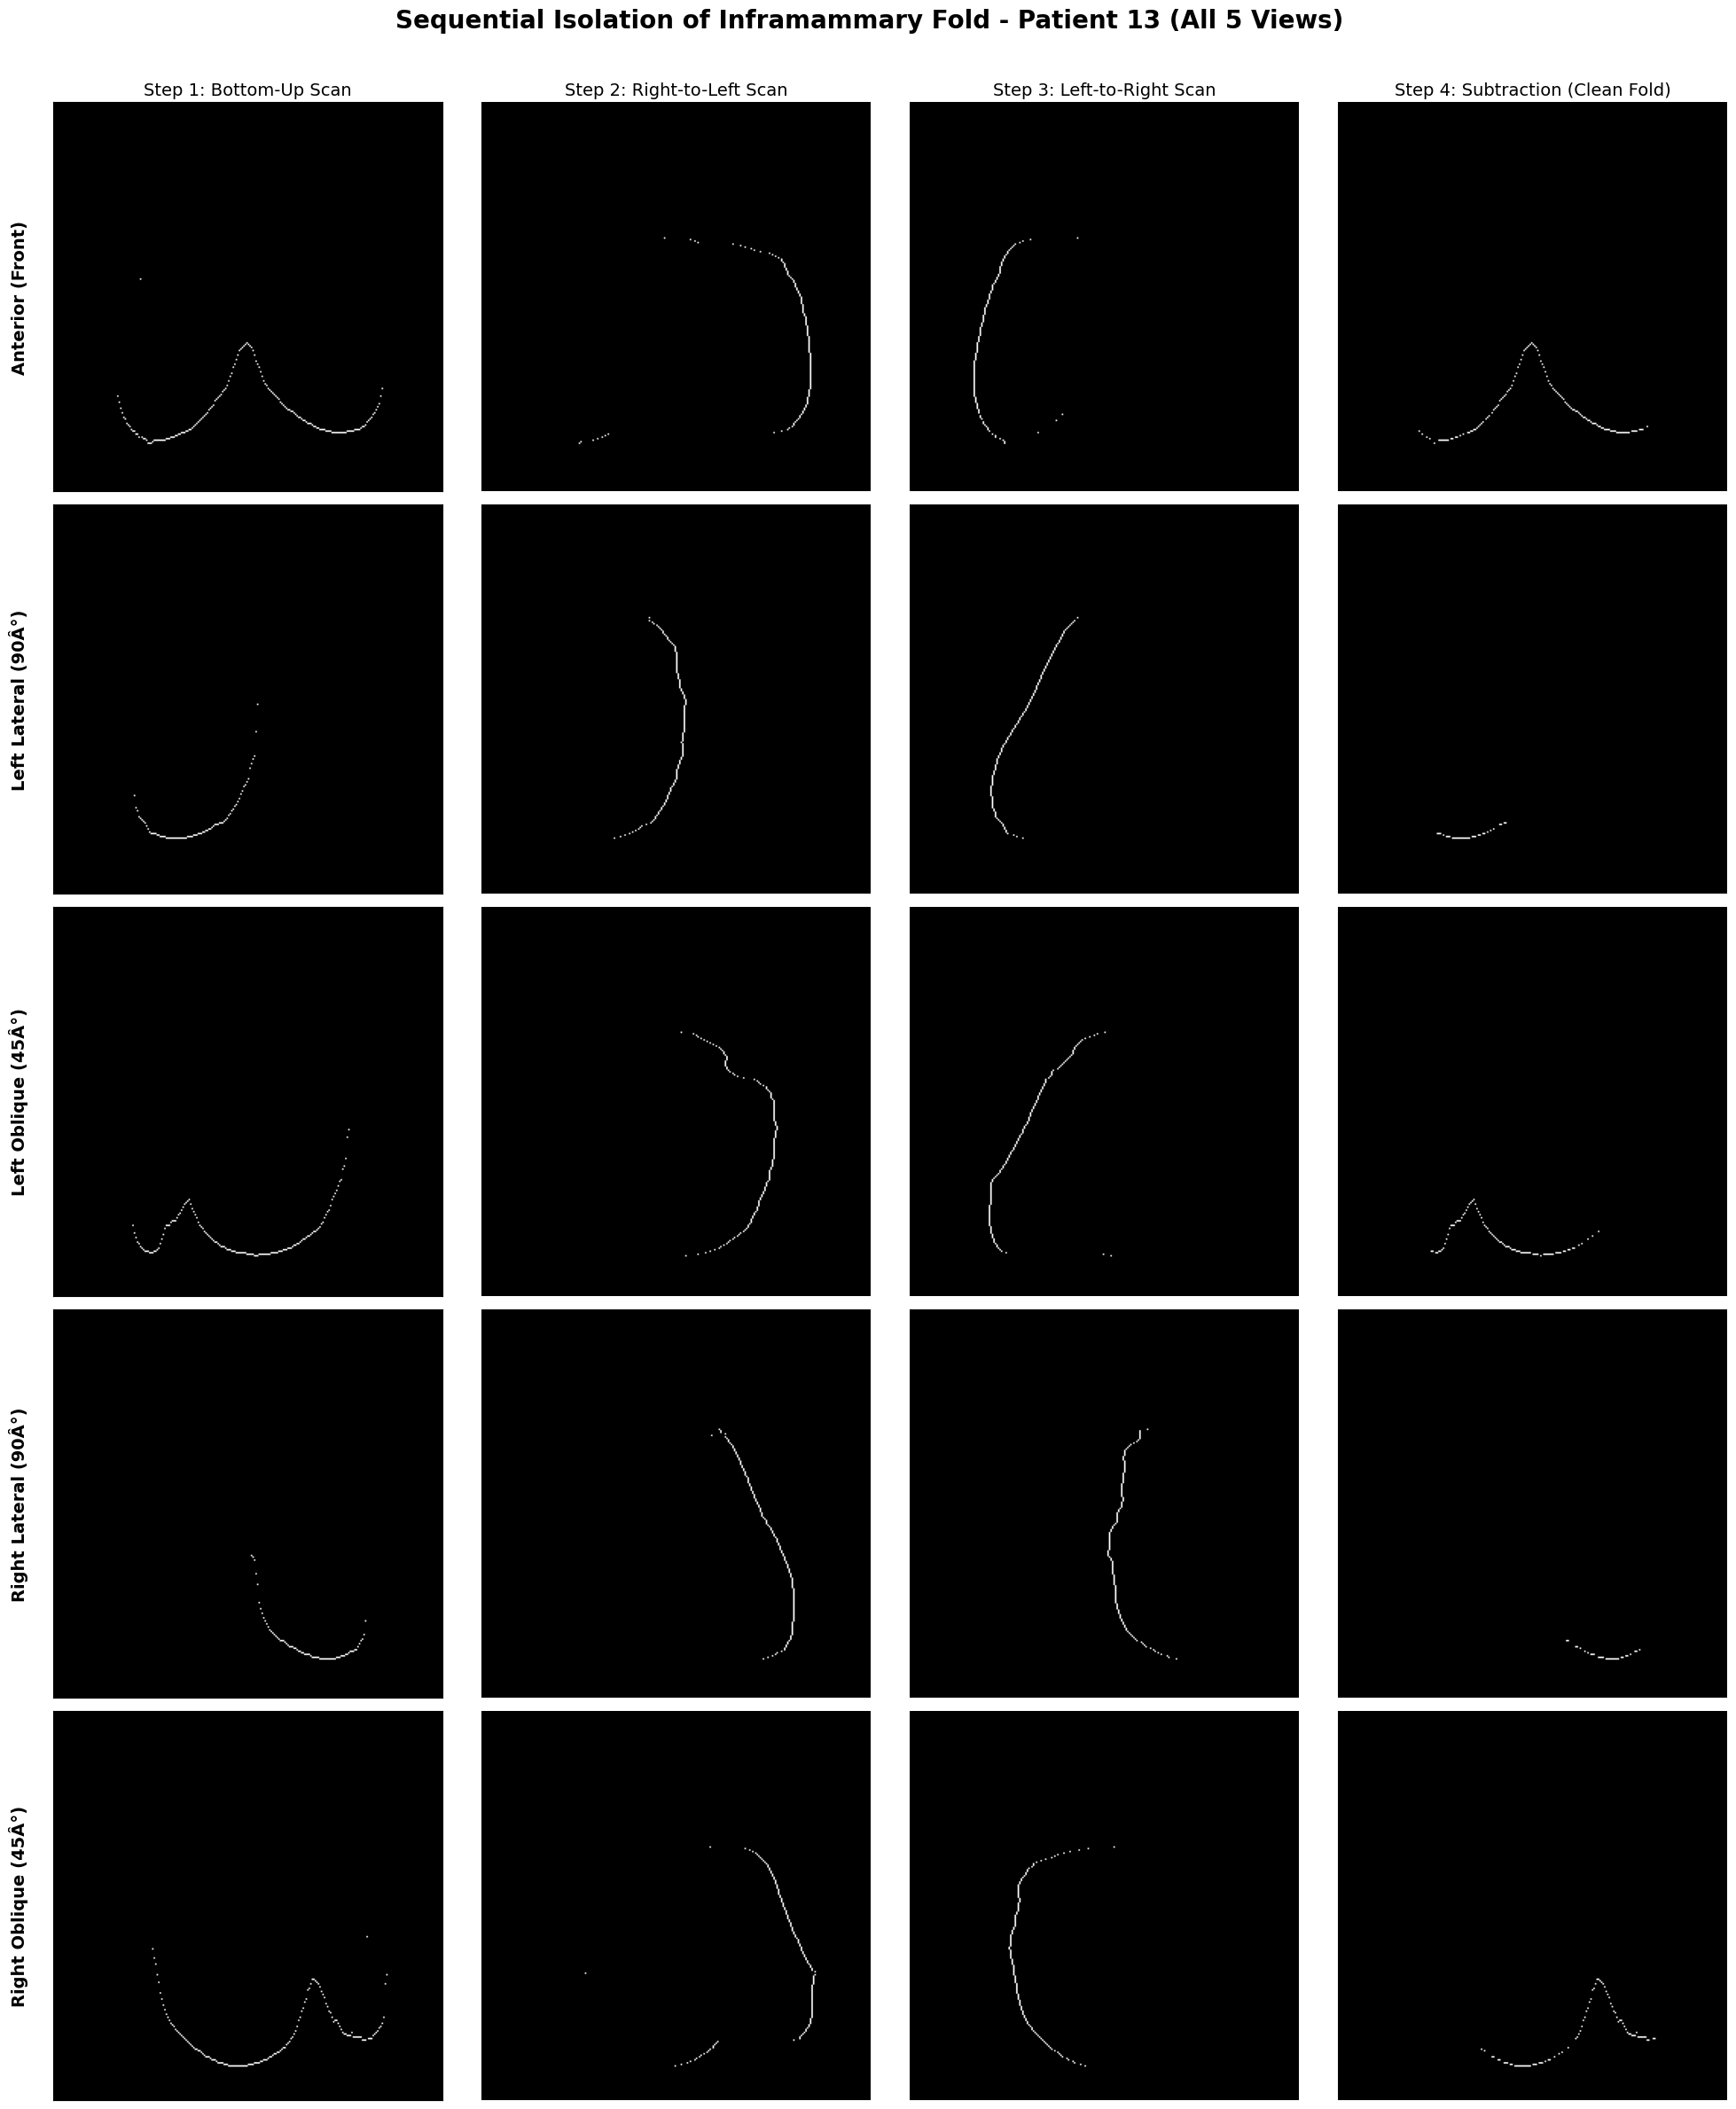

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

def isolate_inframammary_fold_sequential(edge_img):
    """
    Implements the 4-step edge identification from Costa et al. (2023)
    and returns the visual states of all 4 steps.
    """
    h, w = edge_img.shape
    
    # Create blank canvas to store the visual progress of each step
    img_step1 = np.zeros_like(edge_img)
    img_step2 = np.zeros_like(edge_img)
    img_step3 = np.zeros_like(edge_img)
    img_step4 = np.zeros_like(edge_img)
    
    # Coordinate sets for mathematical subtraction
    bottom_pts = set()
    right_pts = set()
    left_pts = set()
    
    # Step 1: Bottom-up search (Find bottom-most pixel per column)
    for x in range(w):
        y_indices = np.where(edge_img[:, x] > 127)[0]
        if len(y_indices) > 0:
            max_y = np.max(y_indices)
            bottom_pts.add((x, max_y))
            img_step1[max_y, x] = 255
            
    # Step 2: Right-to-left search (Find right-most pixel per row)
    for y in range(h):
        x_indices = np.where(edge_img[y, :] > 127)[0]
        if len(x_indices) > 0:
            max_x = np.max(x_indices)
            right_pts.add((max_x, y))
            img_step2[y, max_x] = 255
            
    # Step 3: Left-to-right search (Find left-most pixel per row)
    for y in range(h):
        x_indices = np.where(edge_img[y, :] > 127)[0]
        if len(x_indices) > 0:
            min_x = np.min(x_indices)
            left_pts.add((min_x, y))
            img_step3[y, min_x] = 255
            
    # Step 4: Subtraction (Step 1 MINUS Step 2 MINUS Step 3)
    # This removes the armpit and lateral side lines
    pure_fold = bottom_pts - right_pts - left_pts
    
    for (x, y) in pure_fold:
        img_step4[y, x] = 255
        
    return img_step1, img_step2, img_step3, img_step4

# --- VISUALIZATION EXECUTION FOR 5 VIEWS ---
# The exact paths provided for Patient 233
patient_views = [
    r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Anterior (Front)_edge.png",
    r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Left Lateral (90Â°)_edge.png",
    r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Left Oblique (45Â°)_edge.png",
    r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Right Lateral (90Â°)_edge.png",
    r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Right Oblique (45Â°)_edge.png"
]

# Set up a 5x4 grid plot
fig, axs = plt.subplots(5, 4, figsize=(20, 25))
fig.suptitle("Sequential Isolation of Inframammary Fold - Patient 13 (All 5 Views)", fontsize=20, fontweight='bold')

for i, path in enumerate(patient_views):
    if os.path.exists(path):
        # Using np.fromfile to safely handle Windows paths with special characters like Â°
        img_array = np.fromfile(path, dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
        
        # Extract view name from the file path for titling
        view_name = os.path.basename(path).split('_edge')[0]
        
        # Run the sequential filter
        step1, step2, step3, step4 = isolate_inframammary_fold_sequential(img)
        
        # Plot Step 1
        axs[i, 0].imshow(step1, cmap='gray')
        if i == 0: axs[i, 0].set_title("Step 1: Bottom-Up Scan", fontsize=14)
        axs[i, 0].set_ylabel(view_name, fontsize=14, fontweight='bold', rotation=90, labelpad=20)
        axs[i, 0].set_xticks([])
        axs[i, 0].set_yticks([])
        
        # Plot Step 2
        axs[i, 1].imshow(step2, cmap='gray')
        if i == 0: axs[i, 1].set_title("Step 2: Right-to-Left Scan", fontsize=14)
        axs[i, 1].axis('off')
        
        # Plot Step 3
        axs[i, 2].imshow(step3, cmap='gray')
        if i == 0: axs[i, 2].set_title("Step 3: Left-to-Right Scan", fontsize=14)
        axs[i, 2].axis('off')
        
        # Plot Step 4
        axs[i, 3].imshow(step4, cmap='gray')
        if i == 0: axs[i, 3].set_title("Step 4: Subtraction (Clean Fold)", fontsize=14)
        axs[i, 3].axis('off')
        
    else:
        print(f"Warning: Could not find image at path: {path}")

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to make room for the main title
plt.show()

---
## Phase 4 - Extraction of each view key points

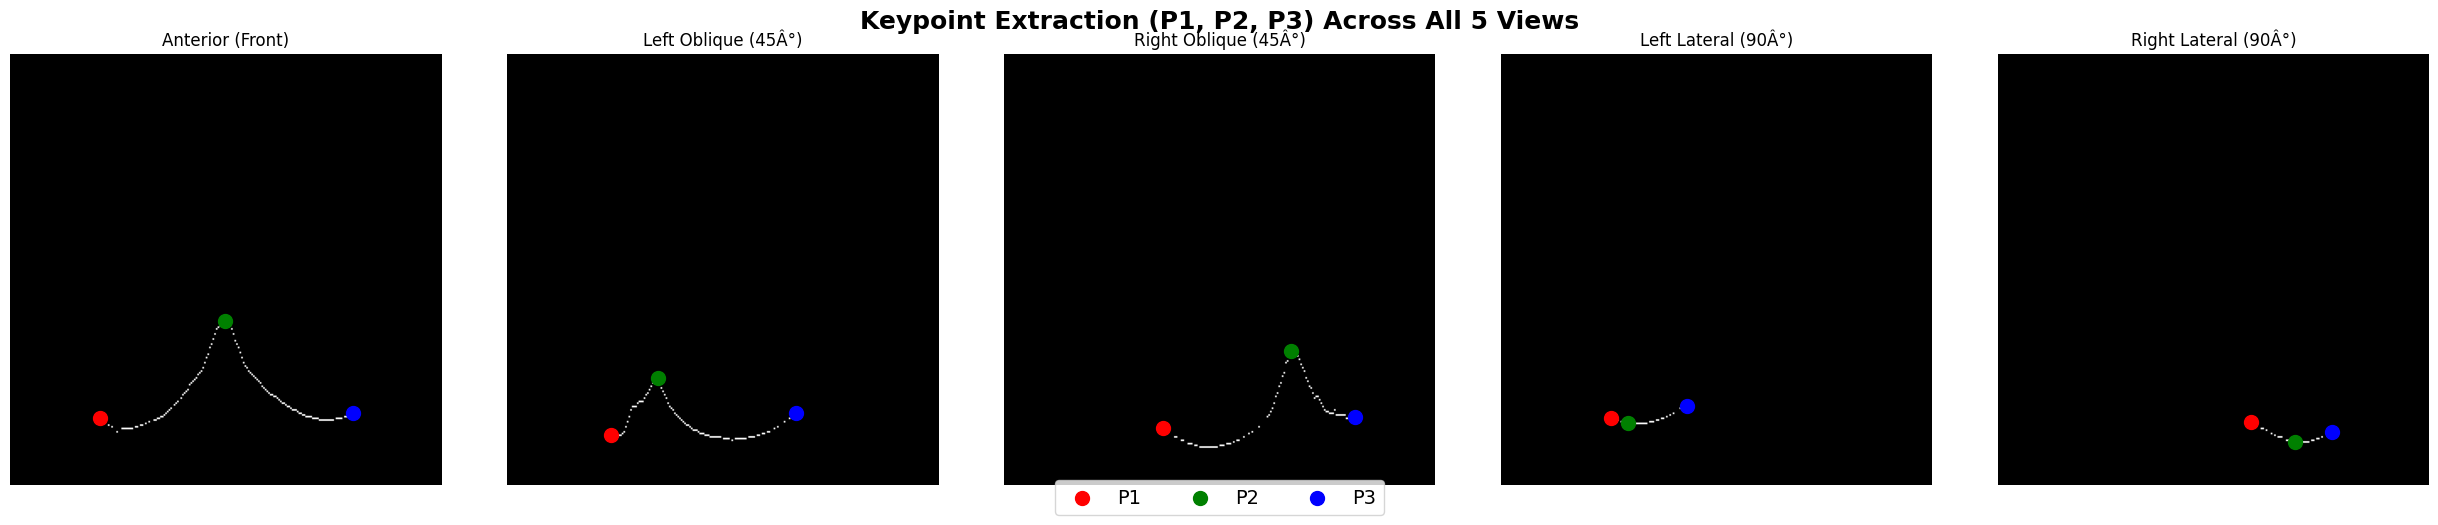

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

def isolate_inframammary_fold(edge_img):
    """
    Implements the 4-step edge identification to isolate the pure lower breast contour.
    Returns the coordinates of the clean fold.
    """
    h, w = edge_img.shape
    bottom_pts, right_pts, left_pts = set(), set(), set()
    
    # Step 1, 2, 3
    for x in range(w):
        y_indices = np.where(edge_img[:, x] > 127)[0]
        if len(y_indices) > 0: bottom_pts.add((x, np.max(y_indices)))
    for y in range(h):
        x_indices = np.where(edge_img[y, :] > 127)[0]
        if len(x_indices) > 0:
            right_pts.add((np.max(x_indices), y))
            left_pts.add((np.min(x_indices), y))
            
    # Step 4: Subtraction
    pure_fold = bottom_pts - right_pts - left_pts
    pure_fold_arr = np.array(list(pure_fold))
    
    # Sort left-to-right by X coordinate
    if len(pure_fold_arr) > 0:
        pure_fold_arr = pure_fold_arr[pure_fold_arr[:, 0].argsort()]
        
    return pure_fold_arr

def extract_keypoints(pure_fold_arr, view_deg):
    """
    Extracts P1, P2, P3 based on Costa et al. (2023) geometric rules.
    """
    if len(pure_fold_arr) == 0:
        return None, None, None

    # P1 and P3 are always the "first points" / "beginning and end" of the sorted curve
    P1 = pure_fold_arr[0]   # Leftmost point (Patient's Right side)
    P3 = pure_fold_arr[-1]  # Rightmost point (Patient's Left side)
    
    if view_deg in [0.0, 45.0, -45.0]:
        # P2: Junction of the curves in the center (Physically highest point -> minimum Y)
        p2_idx = np.argmin(pure_fold_arr[:, 1])
        P2 = pure_fold_arr[p2_idx]

    elif view_deg in [90.0, -90.0]:
        # P2: Lowest point of the curve (Physically lowest point -> maximum Y)
        p2_idx = np.argmax(pure_fold_arr[:, 1])
        P2 = pure_fold_arr[p2_idx]
        
    return tuple(P1), tuple(P2), tuple(P3)

# --- VISUALIZATION EXECUTION FOR ALL 5 VIEWS ---
patient_views = {
    0.0: r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Anterior (Front)_edge.png",
    45.0: r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Left Oblique (45Â°)_edge.png",
    -45.0: r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Right Oblique (45Â°)_edge.png",
    90.0: r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Left Lateral (90Â°)_edge.png",
    -90.0: r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Right Lateral (90Â°)_edge.png"
}

fig, axs = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle("Keypoint Extraction (P1, P2, P3) Across All 5 Views", fontsize=18, fontweight='bold')

for i, (view_deg, path) in enumerate(patient_views.items()):
    if os.path.exists(path):
        # Load image safely
        img_array = np.fromfile(path, dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
        view_name = os.path.basename(path).split('_edge')[0]
        
        # 1. Clean the fold
        pure_curve = isolate_inframammary_fold(img)
        
        # 2. Extract Keypoints
        P1, P2, P3 = extract_keypoints(pure_curve, view_deg)
        
        # 3. Draw Results
        canvas = np.zeros_like(img)
        if len(pure_curve) > 0:
            canvas[pure_curve[:, 1], pure_curve[:, 0]] = 255
            
        axs[i].imshow(canvas, cmap='gray')
        
        if P1 and P2 and P3:
            axs[i].scatter(P1[0], P1[1], c='red', s=100, label='P1' if i==0 else "")
            axs[i].scatter(P2[0], P2[1], c='green', s=100, label='P2' if i==0 else "")
            axs[i].scatter(P3[0], P3[1], c='blue', s=100, label='P3' if i==0 else "")
            
        axs[i].set_title(f"{view_name}", fontsize=12)
        axs[i].axis('off')
    else:
        axs[i].set_title(f"Missing: {view_deg}°")
        axs[i].axis('off')

fig.legend(loc='lower center', ncol=3, fontsize=14, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

---
### Phase 4 - Extraction of each view key points

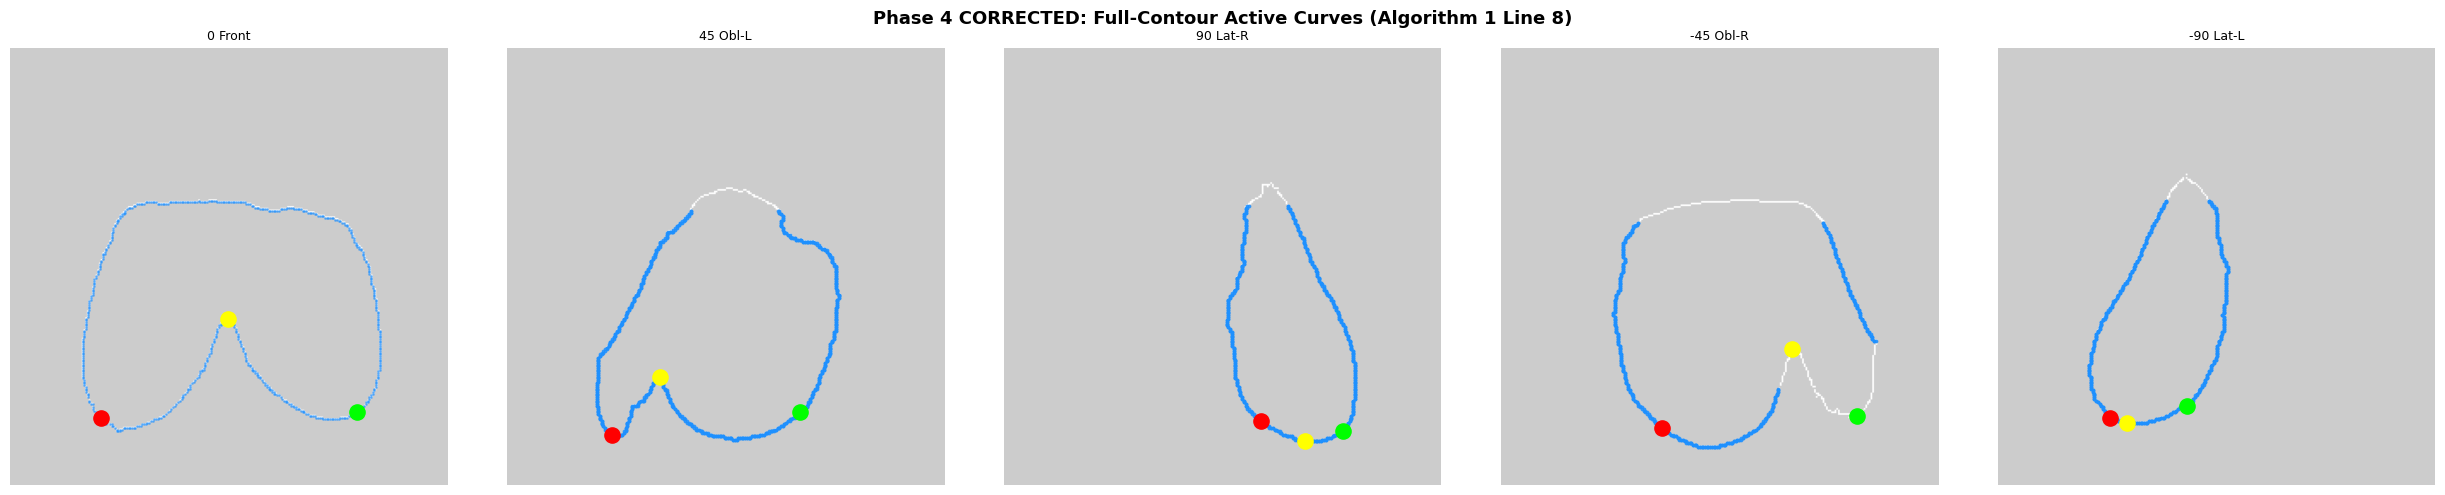

Phase 4 correction verified: full silhouette contour shown for all views.


In [8]:
# Phase 4 — Corrected active-curve extraction
# ================================================================
# BUG in original get_moura_active_curve() (Cell 39):
#   x-threshold clipping returned near-empty or wrong subsets:
#     45 deg  -> cnt[x >= P3[0]] : P3 is already the rightmost pt -> ~0 pts
#     -45 deg -> cnt[x <= P1[0]] : P1 is already the leftmost pt  -> ~0 pts
#     90 deg  -> cnt[x >= P2[0]] : clips wrong half of C-profile
#     -90 deg -> cnt[x <= P1[0]] : same error as -45 deg
#
# FIX (Algorithm 1, Line 8 -- Costa et al. 2023):
#   "Find and store EDGES of 0, 45, -45, 90, -90 degree segmentations."
#   For non-frontal views the COMPLETE silhouette contour (minus the
#   U-Net top rectangular roof artifact) is the correct active curve.
#   Downstream z-filtering (Alg-1 Step 38) handles front/back separation.
#
# Reference:
#   Costa, G.M., Moura, E.L.S., Borchartt, T.B., & Conci, A. (2023).
#   Modeling the 3D Breast Surface Using Thermography.
#   Lecture Notes in Computer Science, 14298, pp. 45-56.
#   https://doi.org/10.1007/978-3-031-44511-8_3

import numpy as np
import cv2
import matplotlib.pyplot as plt
import os


def get_full_contour_edge(edge_img, roof_margin=12):
    """
    Return the COMPLETE largest contour of the segmented region,
    minus the artificial top-roof pixels from the U-Net rectangular mask.

    Implements Algorithm 1 Line 8 (Costa et al., 2023) for all
    non-frontal views (45, 90, -45, -90 degrees).

    Parameters
    ----------
    edge_img    : uint8 grayscale edge image (white pixels = edge)
    roof_margin : px rows to strip from top boundary (default 12)

    Returns
    -------
    ndarray shape (N, 2), columns = (x, y)
    """
    contours, _ = cv2.findContours(
        edge_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.empty((0, 2), dtype=np.int32)
    cnt   = max(contours, key=len).reshape(-1, 2)  # (N,2): (x,y)
    min_y = int(cnt[:, 1].min())
    cnt   = cnt[cnt[:, 1] > min_y + roof_margin]
    return cnt


# ── Visualisation: verify full-contour vs. original clipped output ─────────
patient_views = {
    0.0:   r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Anterior (Front)_edge.png",
    45.0:  r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Left Oblique (45Â°)_edge.png",
    90.0:  r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Right Lateral (90Â°)_edge.png",
    -45.0: r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Right Oblique (45Â°)_edge.png",
    -90.0: r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges3\Patient_13\benign\Left Lateral (90Â°)_edge.png",
}
VLABELS = {0.0:"0 Front", 45.0:"45 Obl-L", 90.0:"90 Lat-R",
           -45.0:"-45 Obl-R", -90.0:"-90 Lat-L"}

fig, axs = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle("Phase 4 CORRECTED: Full-Contour Active Curves (Algorithm 1 Line 8)",
             fontsize=13, fontweight="bold")

for i, (vdeg, path) in enumerate(patient_views.items()):
    ax = axs[i]
    ax.set_title(VLABELS[vdeg], fontsize=9)
    ax.axis("off")
    if not os.path.exists(path):
        ax.text(0.5, 0.5, "File not found", ha="center", transform=ax.transAxes)
        continue
    img  = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap="gray", alpha=0.2)
    pure = isolate_inframammary_fold(img)
    P1, P2, P3 = extract_keypoints(pure, vdeg)
    if vdeg == 0.0:
        ys, xs = np.where(img > 127)
        ax.scatter(xs, ys, c="dodgerblue", s=1, alpha=0.5)
    else:
        active = get_full_contour_edge(img)
        if len(active):
            ax.scatter(active[:, 0], active[:, 1], c="dodgerblue", s=3, alpha=0.8)
    if P1 is not None:
        ax.scatter(*P1, c="red",    s=120, zorder=5)
        ax.scatter(*P2, c="yellow", s=120, zorder=5)
        ax.scatter(*P3, c="lime",   s=120, zorder=5)

plt.tight_layout()
plt.show()
print("Phase 4 correction verified: full silhouette contour shown for all views.")


---
## Phase 5 — Corrected 3-D Geometric Transformation (Costa et al. 2023, §2.2 + Algorithm 1)

### Bugs fixed from original `generate_9_curves_3d_robust`

| # | Bug (original) | Correct per Algorithm 1 |
|---|----------------|------------------------|
| 1 | **Pivot swap** — 90 deg→P3, -90 deg→P1 | §2.2: 90 deg→P1, -90 deg→P3 |
| 2 | **Wrong local origin** — `x -= P3[0]` or `x -= P1[0]` | Step 22: center at LOCAL P2 → `x_c = x - p2_local[0]` |
| 3 | **Active curve** — near-empty from buggy Cell 39 | Full contour from `get_full_contour_edge()` |
| 4 | **Y translation target** — `p2_0[1]` | `pivot_global[1]` (exact paper pivot Y) |

> Costa, G.M. et al. (2023). *Modeling the 3D Breast Surface Using Thermography.*
> LNCS 14298, pp. 45–56. https://doi.org/10.1007/978-3-031-44511-8_3


In [38]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [9]:
# Phase 5 — Corrected 3-D Geometric Transformation
# ================================================================
# Implements Section 2.2 + Algorithm 1 of Costa et al. (2023).
#
# Coordinate system (paper §2.2):
#   X = image horizontal (right)
#   Y = image vertical (downward in image coords)
#   Z = X x Y  (into screen; Z < 0 means toward camera = breast protrudes)
#
# Y-axis rotation Ry(theta) applied to centered point (x_c, y_c, 0):
#   x_rot =  x_c * cos(theta)
#   y_rot =  y_c               (unchanged by Ry)
#   z_rot = -x_c * sin(theta)  (right-of-P2 maps to Z<0 = toward camera)

import numpy as np
import cv2


def generate_9_curves_3d(patient_views, roof_margin=12, verbose=True):
    """
    CORRECTED 3-D curve projection following Algorithm 1 of Costa et al. (2023).

    Returns
    -------
    list of ndarray, each shape (N_i, 3), columns (X, Y, Z).
    Up to 9 arrays corresponding to curves C1...C9.

    Reference:
        Costa, G.M., Moura, E.L.S., Borchartt, T.B., Conci, A. (2023).
        Modeling the 3D Breast Surface Using Thermography.
        Lecture Notes in Computer Science, 14298, pp. 45-56.
        https://doi.org/10.1007/978-3-031-44511-8_3
    """
    curves_3d = []

    if 0.0 not in patient_views:
        raise KeyError("patient_views must contain the 0.0 (frontal) key.")

    img_0 = cv2.imdecode(np.fromfile(patient_views[0.0], dtype=np.uint8),
                         cv2.IMREAD_GRAYSCALE)
    if img_0 is None:
        raise IOError("Cannot read frontal image.")

    pure_0 = isolate_inframammary_fold(img_0)
    p1_0, p2_0, p3_0 = extract_keypoints(pure_0, 0.0)
    if p1_0 is None:
        raise RuntimeError("Cannot extract keypoints from 0 deg view.")

    p1_0 = np.array(p1_0, dtype=float)
    p2_0 = np.array(p2_0, dtype=float)
    p3_0 = np.array(p3_0, dtype=float)

    if verbose:
        print(f"Frontal anchors: P1={p1_0.astype(int)}, "
              f"P2={p2_0.astype(int)}, P3={p3_0.astype(int)}")

    y_idx, x_idx = np.where(img_0 > 127)
    if len(x_idx) == 0:
        raise RuntimeError("No edge pixels found in 0 deg image.")
    pts_0 = np.column_stack((x_idx.astype(float), y_idx.astype(float)))

    # C1: all points to the RIGHT of P1 (paper §2.2, Alg-1 line 36)
    c1 = pts_0[pts_0[:, 0] >= p1_0[0]]
    if len(c1):
        curves_3d.append(np.column_stack((c1, np.zeros(len(c1)))))

    # C2: all points to the LEFT of P3 (paper §2.2, Alg-1 line 35)
    c2 = pts_0[pts_0[:, 0] <= p3_0[0]]
    if len(c2):
        curves_3d.append(np.column_stack((c2, np.zeros(len(c2)))))

    # C3: auxiliary mid-line from P2 up to top of image (Alg-1 line 37)
    top_y = float(pts_0[:, 1].min())
    mid_y = np.linspace(p2_0[1], top_y, 50)
    curves_3d.append(np.column_stack((np.full(50, p2_0[0]), mid_y, np.zeros(50))))

    if verbose:
        print(f"C1={len(c1)}, C2={len(c2)}, C3=50 pts (frontal view)")

    # C4-C9: rotated + auxiliary curves
    # -----------------------------------------------------------------
    # Paper (§2.2):
    #   "edges from 45 and -90 deg views ... positioned over P3 of 0 deg"
    #   "edges from -45 and 90 deg views ... positioned over P1 of 0 deg"
    #
    # BUG in original: 90 deg -> P3, -90 deg -> P1  (SWAPPED vs. paper)
    # FIX: 90 deg -> P1, -90 deg -> P3
    # -----------------------------------------------------------------
    rules = [
        ( 45.0, p3_0,   45.0, "C4:  45 deg oblique-L  -> P3"),
        (-90.0, p3_0,  -90.0, "C5: -90 deg lateral-L  -> P3  [FIXED: was P1]"),
        (-45.0, p1_0,  -45.0, "C6: -45 deg oblique-R  -> P1"),
        ( 90.0, p1_0,   90.0, "C7:  90 deg lateral-R  -> P1  [FIXED: was P3]"),
        ( 45.0, p3_0,  135.0, "C8: aux 135 deg (45 copy) -> P3"),
        (-45.0, p1_0, -135.0, "C9: aux -135 deg (-45 copy) -> P1"),
    ]

    for src_angle, pivot_global, rot_deg, label in rules:
        if src_angle not in patient_views:
            if verbose:
                print(f"  [SKIP] {label} -- view not in patient_views")
            continue

        img_src = cv2.imdecode(
            np.fromfile(patient_views[src_angle], dtype=np.uint8),
            cv2.IMREAD_GRAYSCALE)
        if img_src is None:
            if verbose:
                print(f"  [SKIP] {label} -- cannot read image")
            continue

        pure_src = isolate_inframammary_fold(img_src)
        p1_s, p2_s, p3_s = extract_keypoints(pure_src, src_angle)
        if p1_s is None:
            if verbose:
                print(f"  [SKIP] {label} -- keypoint extraction failed")
            continue
        p2_s = np.array(p2_s, dtype=float)

        # Full contour edge (Phase 4 fix: no x-threshold clipping)
        active = get_full_contour_edge(img_src, roof_margin).astype(float)
        if len(active) == 0:
            if verbose:
                print(f"  [SKIP] {label} -- empty contour")
            continue

        # Alg-1 Step 22: Translate LOCAL P2 to origin
        # BUG original: used p3[0] or p1[0] as x-shift origin
        x_c = active[:, 0] - p2_s[0]
        y_c = active[:, 1] - p2_s[1]

        # Alg-1 Step 23: Ry(theta) rotation around Y-axis
        rad   = np.radians(rot_deg)
        x_rot =  x_c * np.cos(rad)
        y_rot =  y_c                   # Y unchanged by Ry
        z_rot = -x_c * np.sin(rad)    # Z: right-of-P2 -> Z<0 (toward camera)

        # Alg-1 Steps 25/27: Translate rotated origin to global pivot
        # BUG original: y used p2_0[1] instead of pivot_global[1]
        x_f = x_rot + pivot_global[0]
        y_f = y_rot + pivot_global[1]
        z_f = z_rot

        # Alg-1 Step 38: Remove all points with positive Z
        mask   = z_f <= 0
        n_kept = int(mask.sum())
        if verbose:
            print(f"  {label}: {len(active)} pts -> {n_kept} kept (z<=0 filter)")

        if n_kept > 0:
            curves_3d.append(np.column_stack((x_f[mask], y_f[mask], z_f[mask])))
        else:
            if verbose:
                print(f"    WARNING: all pts filtered for rot={rot_deg} deg. "
                      "Check image orientation / z_rot sign convention.")

    return curves_3d


# ── Execute ────────────────────────────────────────────────────────────────
print("=" * 60)
print("Running corrected generate_9_curves_3d() ...")
print("=" * 60)
curves_3d = generate_9_curves_3d(patient_views, verbose=True)
print(f"\nTotal 3-D curves generated: {len(curves_3d)}")
for k, c in enumerate(curves_3d):
    print(f"  Curve {k+1}: {len(c):5d} pts | "
          f"X=[{c[:,0].min():.1f},{c[:,0].max():.1f}] "
          f"Y=[{c[:,1].min():.1f},{c[:,1].max():.1f}] "
          f"Z=[{c[:,2].min():.1f},{c[:,2].max():.1f}]")


Running corrected generate_9_curves_3d() ...
Frontal anchors: P1=[ 53 216], P2=[127 158], P3=[203 213]
C1=502, C2=490, C3=50 pts (frontal view)
  C4:  45 deg oblique-L  -> P3: 808 pts -> 500 kept (z<=0 filter)
  C5: -90 deg lateral-L  -> P3  [FIXED: was P1]: 588 pts -> 183 kept (z<=0 filter)
  C6: -45 deg oblique-R  -> P1: 543 pts -> 402 kept (z<=0 filter)
  C7:  90 deg lateral-R  -> P1  [FIXED: was P3]: 616 pts -> 265 kept (z<=0 filter)
  C8: aux 135 deg (45 copy) -> P3: 808 pts -> 500 kept (z<=0 filter)
  C9: aux -135 deg (-45 copy) -> P1: 543 pts -> 402 kept (z<=0 filter)

Total 3-D curves generated: 9
  Curve 1:   502 pts | X=[53.0,216.0] Y=[89.0,224.0] Z=[0.0,0.0]
  Curve 2:   490 pts | X=[42.0,203.0] Y=[89.0,224.0] Z=[0.0,0.0]
  Curve 3:    50 pts | X=[127.0,127.0] Y=[89.0,158.0] Z=[0.0,0.0]
  Curve 4:   500 pts | X=[203.0,277.2] Y=[116.0,250.0] Z=[-74.2,-0.0]
  Curve 5:   183 pts | X=[203.0,203.0] Y=[130.0,213.0] Z=[-22.0,0.0]
  Curve 6:   402 pts | X=[-21.2,47.3] Y=[142.0,273.0

In [10]:
# Phase 5b — Interactive 3-D visualisation (Fig. 7a equivalent)
import plotly.graph_objects as go
import numpy as np

PALETTE = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
           "#8c564b","#e377c2","#7f7f7f","#bcbd22"]
LABELS  = ["C1: Frontal right-of-P1","C2: Frontal left-of-P3",
           "C3: Mid-line (aux)","C4: 45 oblique-L->P3",
           "C5: -90 lateral-L->P3","C6: -45 oblique-R->P1",
           "C7: 90 lateral-R->P1","C8: Aux 135","C9: Aux -135"]

traces = []
for k, c3d in enumerate(curves_3d):
    label  = LABELS[k] if k < len(LABELS) else f"Curve {k+1}"
    colour = PALETTE[k % len(PALETTE)]
    step   = max(1, len(c3d) // 800)
    cc     = c3d[::step]
    traces.append(go.Scatter3d(
        x=cc[:, 0], y=cc[:, 2], z=-cc[:, 1],
        mode="markers",
        marker=dict(size=1.5, color=colour, opacity=0.85),
        name=label,
    ))

fig = go.Figure(data=traces)
fig.update_layout(
    title="Phase 5 -- 9 Projected Breast Curves (Costa et al. 2023 Fig. 7a equivalent)",
    scene=dict(xaxis_title="X (left-right)", yaxis_title="Z (depth)",
               zaxis_title="-Y (height)",
               camera=dict(eye=dict(x=1.4, y=1.4, z=0.6)),
               aspectmode="data"),
    legend=dict(itemsizing="constant", font=dict(size=9)),
    width=900, height=650,
)
fig.show()
print("3-D curve visualisation complete. Rotate the plot to inspect fanning.")


3-D curve visualisation complete. Rotate the plot to inspect fanning.


In [11]:
# Phase 5c — Degree-4 B-spline fitting for the 9 curves
# Paper §2.2: "The created curves are of degree 4" (Costa et al. 2023)
# Library: scipy.interpolate.splprep / splev
# Ref: Bingol & Krishnamurthy (2019) SoftwareX 9, 85-94  [paper ref 17]
#      https://doi.org/10.1016/j.softx.2018.12.005

from scipy.interpolate import splprep, splev
import numpy as np

DEGREE    = 4     # degree-4 as specified in the paper
N_EVAL    = 200   # evaluation points per fitted curve
MIN_PTS   = DEGREE + 1

fitted_curves = []

for k, c3d in enumerate(curves_3d):
    n = len(c3d)
    if n < MIN_PTS:
        print(f"  Curve {k+1}: only {n} pts -- need >={MIN_PTS} for degree-{DEGREE}, skip")
        fitted_curves.append(None)
        continue

    # Arc-length parameterisation
    diff  = np.diff(c3d, axis=0)
    dist  = np.sqrt((diff ** 2).sum(axis=1))
    t_arc = np.concatenate([[0], np.cumsum(dist)])
    t_arc /= t_arc[-1]

    _, uid = np.unique(t_arc, return_index=True)
    c_u, t_u = c3d[uid], t_arc[uid]

    if len(c_u) < MIN_PTS:
        print(f"  Curve {k+1}: insufficient unique pts after dedup, skip")
        fitted_curves.append(None)
        continue

    try:
        tck, _ = splprep([c_u[:, 0], c_u[:, 1], c_u[:, 2]],
                         u=t_u, k=DEGREE,
                         s=len(c_u) * 0.5, quiet=True)
        xf, yf, zf = splev(np.linspace(0, 1, N_EVAL), tck)
        fitted_curves.append(np.column_stack((xf, yf, zf)))
        print(f"  Curve {k+1}: OK -- {n} input pts -> {N_EVAL} spline pts")
    except Exception as exc:
        print(f"  Curve {k+1}: splprep error: {exc}")
        fitted_curves.append(None)

n_ok = sum(f is not None for f in fitted_curves)
print(f"\nB-spline fitting: {n_ok}/{len(curves_3d)} curves OK.")
print("Use fitted_curves[] as input for Phase 6 NURBS surface.")


  Curve 1: OK -- 502 input pts -> 200 spline pts
  Curve 2: OK -- 490 input pts -> 200 spline pts
  Curve 3: OK -- 50 input pts -> 200 spline pts
  Curve 4: OK -- 500 input pts -> 200 spline pts
  Curve 5: OK -- 183 input pts -> 200 spline pts
  Curve 6: OK -- 402 input pts -> 200 spline pts
  Curve 7: OK -- 265 input pts -> 200 spline pts
  Curve 8: OK -- 500 input pts -> 200 spline pts
  Curve 9: OK -- 402 input pts -> 200 spline pts

B-spline fitting: 9/9 curves OK.
Use fitted_curves[] as input for Phase 6 NURBS surface.


---
## Phase 6 — NURBS Surface Generation + Texture Mapping

From the 9 fitted B-spline control-point sets a NURBS surface is generated
per Costa et al. (2023) §2.2 and §2.3. The frontal thermogram is projected
as a UV texture map (FLIR rain-palette false-colour) onto the resulting mesh.

Library: `geomdl` (NURBS-Python) — cited as reference [17] in the paper.

> Bingol, O.R. & Krishnamurthy, A. (2019). NURBS-Python: an open-source
> object-oriented NURBS modeling framework in Python. *SoftwareX*, 9, 85-94.
> https://doi.org/10.1016/j.softx.2018.12.005


In [12]:
# Phase 6 — NURBS Surface + volume-based colouring (Fig. 7c equivalent)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "geomdl", "-q"], check=True)

from geomdl import fitting
import numpy as np
import plotly.graph_objects as go

ok_curves = [c for c in fitted_curves if c is not None]
print(f"Building NURBS surface from {len(ok_curves)} fitted curves ...")

if len(ok_curves) < 2:
    print("ERROR: need >=2 fitted curves for a surface.")
else:
    grid   = np.stack(ok_curves, axis=0)   # (n_curves, N_EVAL, 3)
    n_rows, n_cols, _ = grid.shape

    ctrl_pts = [[float(grid[r, c, 0]),
                 float(grid[r, c, 1]),
                 float(grid[r, c, 2])]
                for r in range(n_rows) for c in range(n_cols)]

    surf = fitting.approximate_surface(
        ctrl_pts,
        size_u=n_rows, size_v=n_cols,
        degree_u=min(3, n_rows - 1),
        degree_v=min(3, n_cols - 1),
    )
    surf.delta = 0.01   # evaluation step 0.01 (paper §2.2)
    surf.evaluate()
    verts = np.array(surf.evalpts)   # (M, 3)
    print(f"NURBS evaluated: {len(verts)} vertices")

    depth = -verts[:, 2]   # Z<0 -> depth>0 for breast protrusion
    fig_s = go.Figure(data=[go.Scatter3d(
        x=verts[:, 0], y=verts[:, 2], z=-verts[:, 1],
        mode="markers",
        marker=dict(size=1.2, color=depth,
                    colorscale="RdBu_r",   # blue=large protrusion (Fig. 7c)
                    showscale=True,
                    colorbar=dict(title="Depth toward camera")),
    )])
    fig_s.update_layout(
        title="Phase 6 -- NURBS Surface Volume-Based Colouring (Fig. 7c equivalent)",
        scene=dict(xaxis_title="X", yaxis_title="Z (depth)", zaxis_title="-Y (height)",
                   aspectmode="data"),
        width=900, height=650,
    )
    fig_s.show()
    print("NURBS surface rendering complete.")
    print("For UV texture mapping (Fig. 8), apply the frontal TIFF as a UV map")
    print("using OpenGL (as in the paper) or matplotlib Axes3D.plot_surface facecolors.")


Building NURBS surface from 9 fitted curves ...
NURBS evaluated: 10000 vertices


NURBS surface rendering complete.
For UV texture mapping (Fig. 8), apply the frontal TIFF as a UV map
using OpenGL (as in the paper) or matplotlib Axes3D.plot_surface facecolors.
